In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import silhouette_score


In [50]:
df2 = pd.read_csv('C:/3курс/DS/films/movies_metadata.csv')
df1 = pd.read_csv('C:/3курс/DS/films/ratings_small.csv')

In [51]:
df1.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [52]:
df2.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [53]:
df2['id'] = pd.to_numeric(df2['id'], errors='coerce').fillna(0).astype(int)
df2 = df2.drop_duplicates('id')
df1 = df1.drop(['timestamp'], axis = 1)

In [54]:
df1

,userId,movieId,rating
0,1,31,2.5
1,1,1029,3.0
2,1,1061,3.0
3,1,1129,2.0
4,1,1172,4.0
...,...,...,...
99999,671,6268,2.5
100000,671,6269,4.0
100001,671,6365,4.0
100002,671,6385,2.5


In [55]:
user_arr = []

for i in range(1, 671):
    user_data = df1[df1['userId'] == i]
    num_films = len(user_data)  # количество фильмов
    avg_rating = user_data['rating'].mean()  # средний рейтинг
    user_arr.append([num_films, avg_rating])

user_arr = np.array(user_arr)
X = user_arr

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scal = scaler.fit_transform(user_arr)

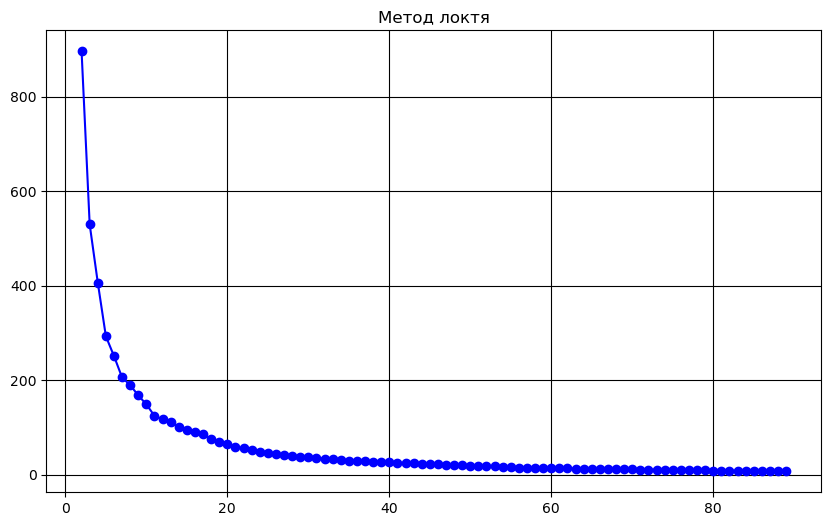

In [57]:
#Метод локтя
from sklearn.cluster import KMeans

arr_score = []

for i in range(2, 90):
    kmeans = KMeans(n_clusters = i, random_state = 0, n_init = "auto", max_iter = 500).fit(X_scal)
    score = kmeans.inertia_
    arr_score.append(score)

plt.figure(figsize = (10, 6))
plt.title('Метод локтя')
plt.plot(range(2, 90), arr_score, 'bo-')
plt.grid(True, color = 'k')
plt.show()

In [58]:
#residual_arr = []

#for i in range(len(arr_score) - 1):
   # res = arr_score[i + 1] - arr_score[i]
   # residual_arr.append(res)

#plt.figure(figsize = (4, 2))
#plt.title('residuals')
#plt.plot(residual_arr, '-')
#plt.grid(True, color = 'k')

In [59]:
kmeans = KMeans(n_clusters = 5, random_state = 0, n_init = "auto", max_iter = 500).fit(X_scal)
score = kmeans.inertia_
arr_score.append(score)
labels = kmeans.labels_

In [60]:
arr_points = []

for i in range(5):
    temp = []
    for j in range(len(labels)):
        if labels[j] == i:
            temp.append(X[j])
    arr_points.append(temp)

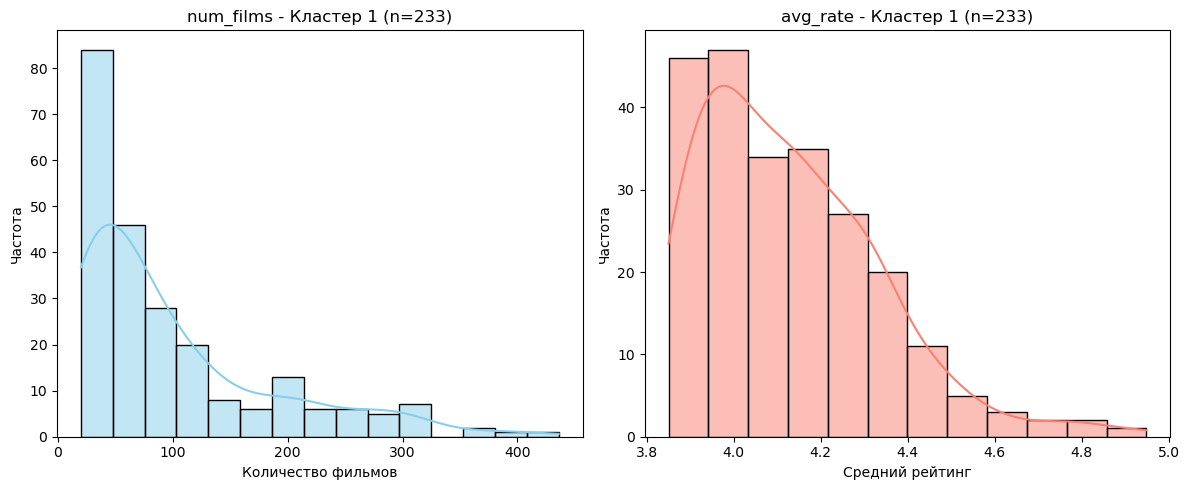

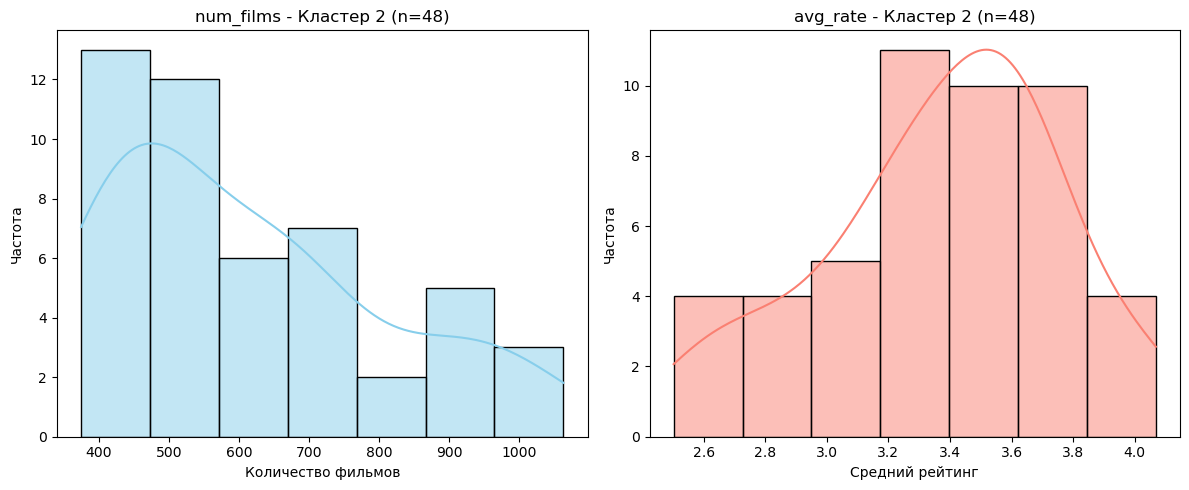

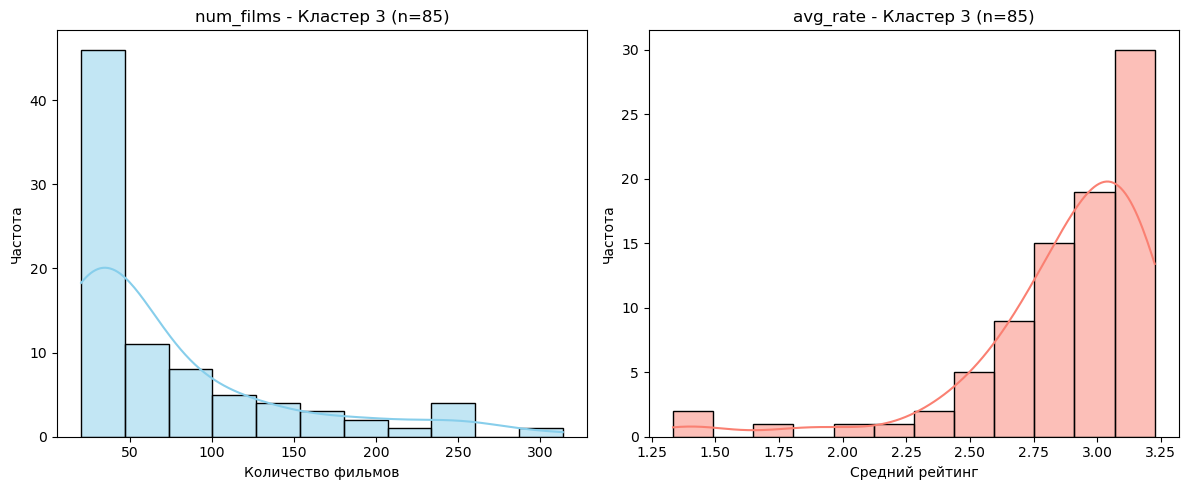

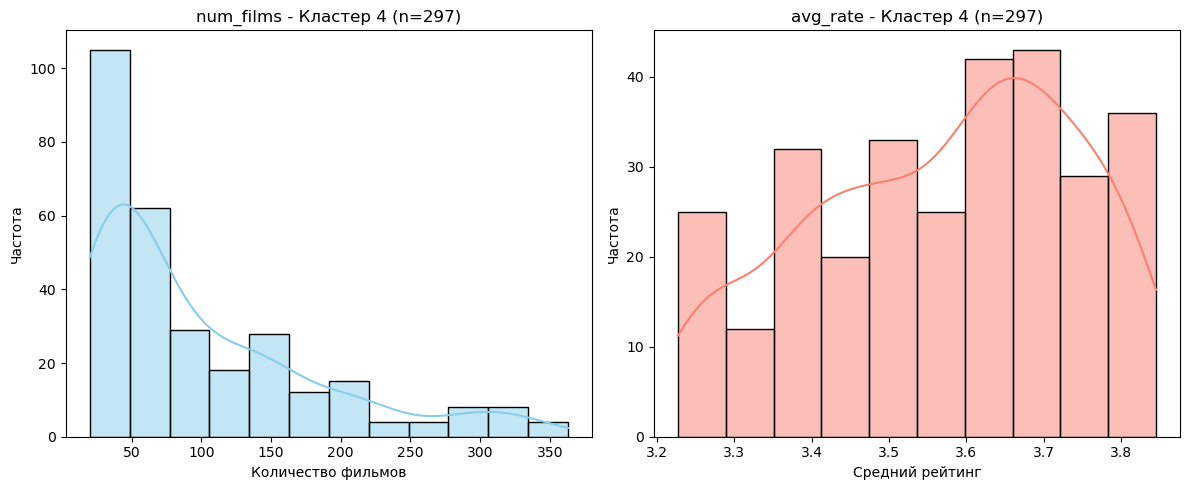

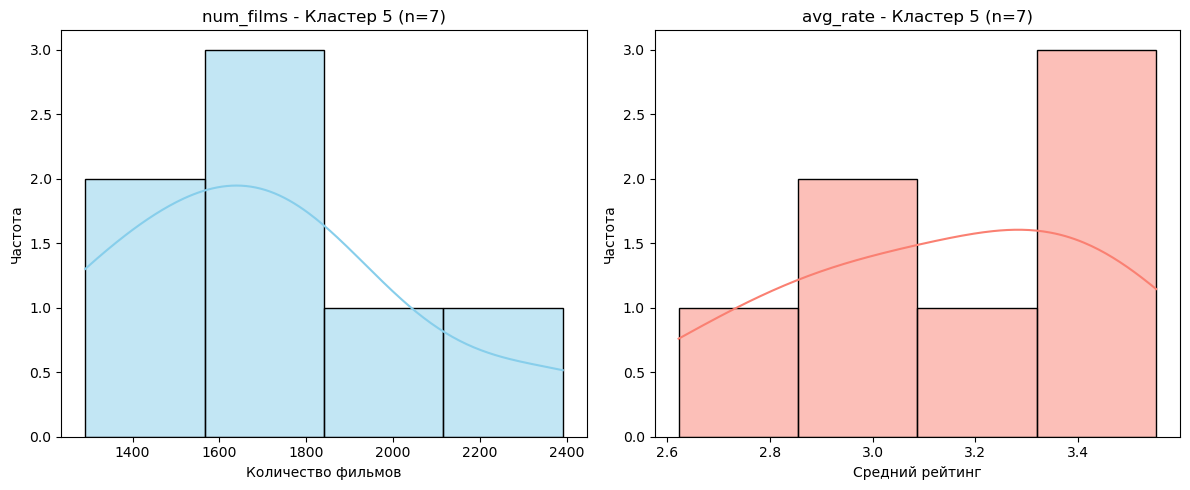

In [61]:
import seaborn as sns
labels_names = ['num_films', 'avg_rate']
for j in range(5):
    if len(arr_points[j]) > 0:  # Проверяем, что кластер не пустой
        arr = np.array(arr_points[j])
        
        # Создаем два подграфика
        fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))
        
        # Гистограмма для количества фильмов
        sns.histplot(arr[:, 0], ax=ax1, kde=True, color='skyblue')
        ax1.set_title(f'{labels_names[0]} - Кластер {j+1} (n={len(arr)})')
        ax1.set_xlabel('Количество фильмов')
        ax1.set_ylabel('Частота')
        
        # Гистограмма для среднего рейтинга
        sns.histplot(arr[:, 1], ax=ax2, kde=True, color='salmon')
        ax2.set_title(f'{labels_names[1]} - Кластер {j+1} (n={len(arr)})')
        ax2.set_xlabel('Средний рейтинг')
        ax2.set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()



In [62]:
unique_combinations = df1[['userId', 'movieId']].drop_duplicates()
print(f"Уникальных комбинаций пользователь-фильм: {len(unique_combinations)}")

Уникальных комбинаций пользователь-фильм: 100004


In [63]:
sil_score = silhouette_score(X_scal, labels)
print(sil_score)

0.41597175359419414
